Plot saved correctly.


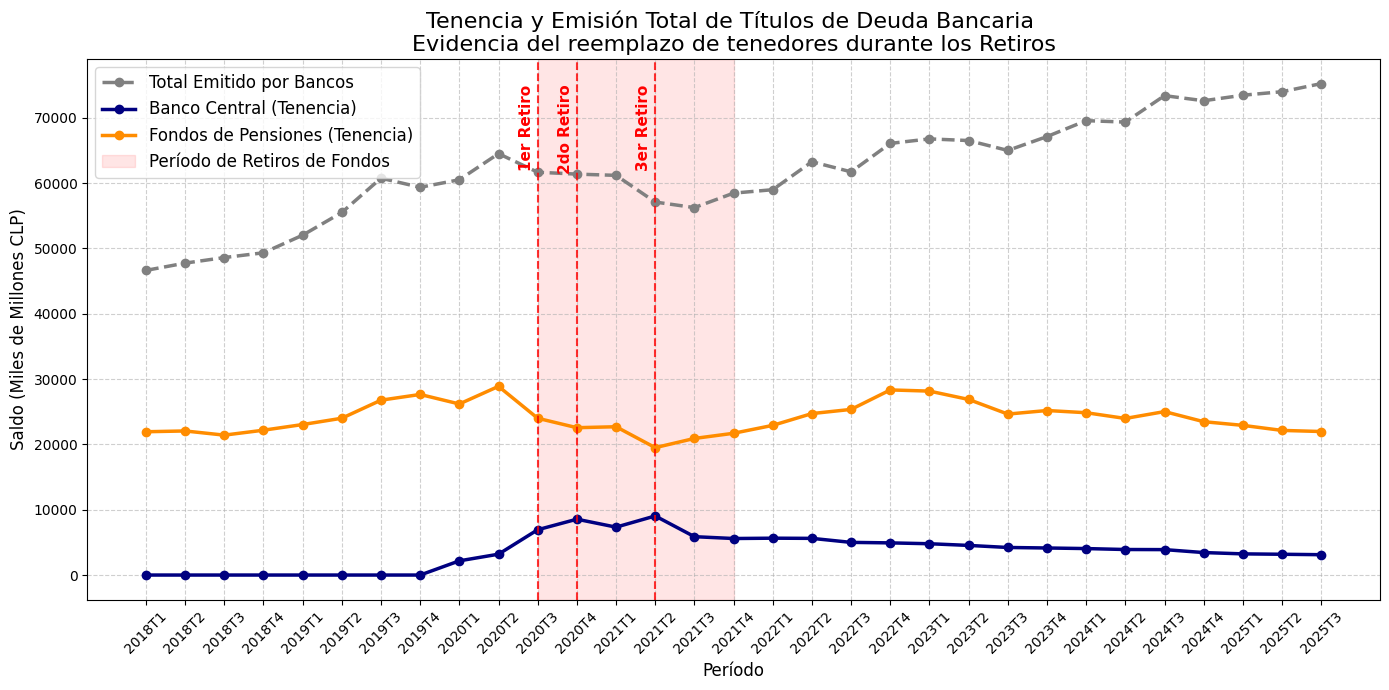

In [ ]:
"""
================================================================================
TESIS MAGÍSTER EN ECONOMÍA UC
Contagio predictivo sectorial y NBFIs en Chile
================================================================================
Script: plot_bonos.ipynb
Autor:  Carlos González
Fecha:  Abril 2026
Ultima actualizacion: Mayo 2026

Grafico de bonos bancarios en tenencia de BC y FP
"""
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../../1_datos/1_clean_data/panel_matriz_saldos.csv')

# Filtrar bonos emitidos por bancos (S122) y desde 2018
df_bonds = df[(df['instrumento'] == 'Titulos deuda') & (df['sector_pasivo_codigo'] == 'S122') & (df['año'] >= 2018)]

# Total de pasivos emitidos por bancos (suma de todos los tenedores)
df_total = df_bonds.groupby(['periodo', 'año', 'trimestre'])['valor'].sum().reset_index().rename(columns={'valor': 'Total Emisión Bancos'})

# Obtener series de BC (S121) y FP (S129)
df_bc = df_bonds[df_bonds['sector_activo_codigo'] == 'S121'][['periodo', 'año', 'trimestre', 'valor']].rename(columns={'valor': 'Banco Central'})
df_fp = df_bonds[df_bonds['sector_activo_codigo'] == 'S129'][['periodo', 'año', 'trimestre', 'valor']].rename(columns={'valor': 'Fondos de Pensiones'})

# Obtener todos los periodos desde 2018 posibles ordenados para el eje X
all_periods = df[df['año'] >= 2018][['periodo', 'año', 'trimestre']].drop_duplicates().sort_values(['año', 'trimestre'])

# Unir ambos DataFrames al eje temporal completo
df_merged = pd.merge(all_periods, df_bc, on=['periodo', 'año', 'trimestre'], how='left')
df_merged = pd.merge(df_merged, df_fp, on=['periodo', 'año', 'trimestre'], how='left')
df_merged = pd.merge(df_merged, df_total, on=['periodo', 'año', 'trimestre'], how='left')

# Rellenar nulos con 0 y ordenar
df_merged.fillna(0, inplace=True)
df_merged = df_merged.sort_values(by=['año', 'trimestre'])

plt.figure(figsize=(14, 7))

# Graficar el Total
plt.plot(df_merged['periodo'], df_merged['Total Emisión Bancos'], label='Total Emitido por Bancos', color='gray', linestyle='--', linewidth=2.5, marker='o')

# Graficar BC y FP
plt.plot(df_merged['periodo'], df_merged['Banco Central'], label='Banco Central (Tenencia)', color='navy', linewidth=2.5, marker='o')
plt.plot(df_merged['periodo'], df_merged['Fondos de Pensiones'], label='Fondos de Pensiones (Tenencia)', color='darkorange', linewidth=2.5, marker='o')

# Highlight Retiros (2020T3 - 2021T4) area background
periods = df_merged['periodo'].tolist()
try:
    idx_start = periods.index('2020T3')
    idx_end = periods.index('2021T4')
    plt.axvspan(idx_start, idx_end, color='red', alpha=0.10, label='Período de Retiros de Fondos')
except ValueError:
    pass

# Marcar los 3 retiros (2020T3, 2020T4, 2021T2)
retiros_qs = ['2020T3', '2020T4', '2021T2']
labels_retiros = ['1er Retiro', '2do Retiro', '3er Retiro']
for r_q, l_r in zip(retiros_qs, labels_retiros):
    if r_q in periods:
        idx = periods.index(r_q)
        plt.axvline(x=idx, color='red', linestyle='--', alpha=0.8)
        plt.text(idx - 0.1, plt.gca().get_ylim()[1]*0.95, l_r, color='red', rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=11, fontweight='bold')

plt.xticks(rotation=45)
plt.title('Tenencia y Emisión Total de Títulos de Deuda Bancaria \nEvidencia del reemplazo de tenedores durante los Retiros', fontsize=16)
plt.xlabel('Período', fontsize=12)
plt.ylabel('Saldo (Miles de Millones CLP)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Guardar en la carpeta solicitada
out_dir = '../../3_resultados/3_resultados_he_red/figuras/3_apendices_dy'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'tenencia_bonos_bancarios.png'), dpi=300)

# Guardar también en los artefactos para refrescar la UI
out_dir_artifact = '/Users/carlosgonzalez/.gemini/antigravity/brain/ca7d91f0-5971-42a5-9407-04eb7da4a381'
os.makedirs(out_dir_artifact, exist_ok=True)
plt.savefig(os.path.join(out_dir_artifact, 'tenencia_bonos.png'), dpi=300)

print("Plot saved correctly.")

